# Social Media Dataset From Reddit

Source of Dataset: https://huggingface.co/datasets/emilpartow/reddit_finance_posts_sp500

Summary: Implemented stock tickers, weighting, and daily sentiment analysis on a social media dataset. The code generates daily sentiment scores, which can be used to help predict movements in the S&P 500.

For setup:
1. Ensure you are running on a GPU, as the code utilizes a neural network and requires GPU acceleration for efficient performance.
2. Processing a one-year dataset (e.g., 2024–2025) takes approximately 20 minutes.
3. The current code processes data from 2022–2023.
4. The existing dataset supports predictions for the period from 2008 to July 2025.
5. A separate script is provided to combine datasets across multiple years, making it easy to update and extend the training data.

## Step 1: Enhanced Data Preprocessing with Ticker Extraction

**Core Workflow**
- Environment Setup: Loads NLP (transformers), Data (datasets), and Finance (yfinance) libraries.

- Ticker Acquisition: Fetches a valid list of S&P 500 symbols from GitHub/DataHub with a manual backup.

- Data Filtering: Truncates the dataset to posts for each calendar year.

- Extraction Logic: Uses Regex to find tickers (e.g., $TSLA or AAPL) in both post titles and body text.

- Validation: Cross-references findings against the S&P 500 list to remove noise (e.g., "A", "FOR", "I").

- Summary: Outputs the percentage of posts containing valid tickers and displays sample results.

**Key Metrics Produced**
1) tickers: A unique list of stocks mentioned per post.
2) has_ticker: A boolean flag for easy filtering.
3) ticker_count: The volume of different stocks discussed in a single thread.

In [1]:
!pip install -U transformers datasets evaluate accelerate yfinance --quiet

import pandas as pd
import numpy as np
import torch
import re
from datetime import datetime
from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from transformers import TrainingArguments, Trainer
import evaluate
import yfinance as yf
from collections import Counter

# Load dataset
from datasets import load_dataset
dataset = load_dataset("emilpartow/reddit_finance_posts_sp500")
df = dataset['train'].to_pandas()

print(df.head())

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 75.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.0/527.0 kB 22.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.8/130.8 kB 15.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 88.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 17.0 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

00_combined.csv:   0%|          | 0.00/2.46G [00:00<?, ?B/s]

Generating train split:   0%|          | 0/431923 [00:00<?, ? examples/s]

        id                                              title  \
0  1lidh6b          $KO, $PEP and the new Texas health labels   
1  1jkjhwe           Basic Stock Analysis Guide for Beginners   
2  1jiqe9p  These are the stocks on my watchlist (03/24) -...   
3  1jb3ph1  These are the stocks on my watchlist (03/14) -...   
4  1j8qi84       These are the stocks on my watchlist (03/11)   

                                                text   created_utc  \
0  Today I saw that Texas are making companies li...  1.750676e+09   
1  **Yo! Made this for some buddies and thought i...  1.743015e+09   
2  This is a daily watchlist for short-term tradi...  1.742822e+09   
3  This is a daily watchlist for short-term tradi...  1.741958e+09   
4  This is a daily watchlist for short-term tradi...  1.741699e+09   

      created_datetime                author  score  num_comments  \
0  2025-06-23 10:50:33  Nearby_Valuable_5467     10             7   
1  2025-03-26 18:54:12           LadsoStocks     6

In [2]:
# Get S&P 500 tickers
def get_sp500_tickers():
    """Get S&P 500 tickers with fallback options"""
    try:
        # Try GitHub CSV first (most reliable)
        url = 'https://raw.githubusercontent.com/datasets/s-and-p-500-companies/main/data/constituents.csv'
        sp500_df = pd.read_csv(url)
        tickers = set(sp500_df['Symbol'].tolist())
        print(f"✓ Loaded {len(tickers)} S&P 500 tickers from GitHub")
        return tickers
    except:
        pass

    try:
        # Alternative source
        url = 'https://datahub.io/core/s-and-p-500-companies/r/constituents.csv'
        sp500_df = pd.read_csv(url)
        tickers = set(sp500_df['Symbol'].tolist())
        print(f"✓ Loaded {len(tickers)} S&P 500 tickers from DataHub")
        return tickers
    except:
        pass

    # Manual comprehensive list (top 70 most traded)
    print("Using comprehensive manual ticker list...")
    tickers = {
        'AAPL', 'MSFT', 'GOOGL', 'AMZN', 'NVDA', 'META', 'TSLA', 'BRK.B', 'UNH', 'JNJ',
        'JPM', 'V', 'PG', 'XOM', 'HD', 'CVX', 'MA', 'ABBV', 'PEP', 'COST',
        'AVGO', 'ADBE', 'CRM', 'TMO', 'ACN', 'ABT', 'DHR', 'NFLX', 'DIS', 'WMT',
        'VZ', 'CMCSA', 'NKE', 'PYPL', 'AMD', 'INTC', 'TXN', 'QCOM', 'AMGN', 'IBM',
        'CAT', 'GS', 'C', 'WFC', 'AXP', 'BA', 'GE', 'MMM', 'HON', 'UPS',
        'LMT', 'RTX', 'NEE', 'DUK', 'SO', 'MO', 'KO', 'MCD', 'SBUX', 'TGT',
        'BLK', 'SCHW', 'SPGI', 'PLD', 'AMT', 'CCI', 'EQIX', 'PSA', 'O', 'DLR'
    }
    print(f"✓ Using manual list of {len(tickers)} tickers")
    return tickers

sp500_tickers = get_sp500_tickers()

# Enhanced ticker extraction function
def extract_tickers(text, sp500_tickers):
    """Extract S&P 500 tickers from text"""
    if pd.isna(text):
        return []
    text = str(text).upper()
    # Pattern for $TICKER
    pattern1 = r'\$([A-Z]{1,5}\.?[A-Z]?)'
    # Pattern for standalone tickers
    pattern2 = r'\b([A-Z]{1,5}\.?[A-Z]?)\b'

    found_tickers = set()
    for pattern in [pattern1, pattern2]:
        matches = re.findall(pattern, text)
        for match in matches:
            # Clean ticker
            match = match.replace('.', '')
            if match in sp500_tickers:
                found_tickers.add(match)
    return list(found_tickers)

# Apply ticker extraction
df['created_datetime'] = pd.to_datetime(df['created_datetime'], errors='coerce')
df = df[(df['created_datetime'] >= '2022-01-01') & (df['created_datetime'] <= '2022-12-31')]

print(f"Total posts after date filter: {len(df)}")

# Extract tickers
print("Extracting tickers from titles...")
df['tickers_title'] = df['title'].apply(lambda x: extract_tickers(x, sp500_tickers))

print("Extracting tickers from text...")
df['tickers_text'] = df['text'].apply(lambda x: extract_tickers(x, sp500_tickers))

# Combine tickers
df['tickers'] = df['tickers_title'] + df['tickers_text']
df['tickers'] = df['tickers'].apply(lambda x: list(set(x)))  # Remove duplicates
df['has_ticker'] = df['tickers'].apply(lambda x: len(x) > 0)
df['ticker_count'] = df['tickers'].apply(len)

print(f"Posts with tickers: {df['has_ticker'].sum()}/{len(df)} ({df['has_ticker'].mean()*100:.1f}%)")

# Show sample of extracted tickers
sample_with_tickers = df[df['has_ticker']].head(3)
for idx, row in sample_with_tickers.iterrows():
    print(f"\nTitle: {row['title'][:100]}...")
    print(f"Extracted tickers: {row['tickers']}")

✓ Loaded 503 S&P 500 tickers from GitHub
Total posts after date filter: 52850
Extracting tickers from titles...
Extracting tickers from text...
Posts with tickers: 49086/52850 (92.9%)

Title: Thoughts on 3M?...
Extracted tickers: ['ON', 'IT', 'HAS', 'A']

Title: How are dividends accounted for in the stock chart performance?...
Extracted tickers: ['ARE', 'A', 'IT', 'HAS']

Title: The first inversion is the 1Y/2Y yield. Does that mean the bond market predicts rate cuts occurring ...
Extracted tickers: ['NOW', 'IT', 'ARE', 'ALL', 'SO']


## Step 2: Weighted Sentiment with Ticker Enhancement

**Key Logic: The "Weighted Sentiment" Formula**

1. VADER Integration: It uses the nltk VADER tool to generate "compound" scores (ranging from -1 to 1) for both the title and the body text.

2. Weighted Averaging: It prioritizes the Title (60%) over the Body Text (40%), assuming titles carry the core "hook" or bias of the post.

3. Ticker Boosting: * If a post mentions a valid S&P 500 ticker, the sentiment score is multiplied by 1.2 (a 20% "boost" in intensity).
  - Calculates a Confidence Score based on how many tickers are mentioned (more tickers = higher confidence).

4. Threshold Labeling: It converts the raw scores into categories:
  Positive (1): Score > 0.1;
  Negative (0): Score < -0.1;
  Neutral (-1): Scores in between.

5. Data Filtering
The code creates a refined dataset (df_filtered) by discarding posts with a Confidence Score of 0.3 or lower. This ensures the final analysis only includes posts that are clearly about specific stocks rather than general market chatter.

In [3]:
from nltk.sentiment import SentimentIntensityAnalyzer
import nltk
nltk.download('vader_lexicon')

sia = SentimentIntensityAnalyzer()

def get_weighted_sentiment(row, title_weight=0.6, text_weight=0.4):
    """Calculate weighted sentiment with ticker boost"""
    title_sentiment = sia.polarity_scores(str(row['title']))['compound']
    text_sentiment = sia.polarity_scores(str(row['text']))['compound']

    # Base weighted sentiment
    base_sentiment = title_weight * title_sentiment + text_weight * text_sentiment

    # Ticker boost: if ticker mentioned, sentiment is more reliable
    ticker_boost = 1.2 if row['has_ticker'] else 1.0
    ticker_confidence = min(1.0, row['ticker_count'] * 0.1) if row['has_ticker'] else 0

    # Enhanced sentiment with ticker confidence
    enhanced_sentiment = base_sentiment * ticker_boost

    # Cap sentiment at [-1, 1]
    enhanced_sentiment = max(-1.0, min(1.0, enhanced_sentiment))

    return enhanced_sentiment, ticker_confidence

# Apply weighted sentiment
df[['enhanced_sentiment', 'ticker_confidence']] = df.apply(
    lambda row: pd.Series(get_weighted_sentiment(row)), axis=1
)

# Create labels with confidence threshold
df['label'] = df['enhanced_sentiment'].apply(lambda x: 1 if x > 0.1 else (0 if x < -0.1 else -1))
df['label_binary'] = df['label'].apply(lambda x: 1 if x == 1 else 0)

# Filter low confidence samples if needed
df_filtered = df[df['ticker_confidence'] > 0.3]  # Keep only confident predictions
print(f"After confidence filtering: {len(df_filtered)} samples")

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


After confidence filtering: 45519 samples


## Step 3: Enhanced Text Processing.
Performs Feature Engineering and Data Balancing to optimize the dataset for a Transformer model.

1. Text Augmentation (create_enhanced_text)
- The script "upweights" important information so a Transformer model (like BERT or RoBERTa) pays more attention to it:
- **Ticker Markers:** It prepends a special tag [TICKERS: AAPL, TSLA] to the start of the text. This gives the model immediate context about which companies are being discussed.
- **Title Boosting:** Since titles usually contain the most concentrated sentiment, the code triples the title text if tickers are present (or doubles it if not). This "repetition trick" effectively tells the model: "Pay 3x more attention to these words."

2. Class Balancing
- Machine learning models struggle if one category has 90% of the data and the other has 10% (they simply learn to guess the majority). This code fixes that by:
- Equal Sampling: It identifies the smaller group (either Positive or Negative) and takes an equal number of samples from both.
- Capping: It limits the total dataset to a maximum of 50,000 samples (25,000 per class) to ensure training remains computationally efficient.

In [4]:
# Create enhanced text with ticker information
def create_enhanced_text(row):
    """Create text with ticker markers for better model understanding"""
    title = str(row['title'])
    text = str(row['text'])
    tickers = row['tickers']

    # Add ticker markers
    ticker_marker = f"[TICKERS: {', '.join(tickers)}] " if tickers else ""

    # Combine with weights indicated by repetition (simplified approach)
    weighted_title = title * 3 if tickers else title * 2  # Boost title weight
    weighted_text = text if tickers else text * 1

    enhanced = f"{ticker_marker}{weighted_title}. {weighted_text}"
    return enhanced

df['enhanced_text'] = df.apply(create_enhanced_text, axis=1)

# Sample balanced dataset
df_positive = df[df['label_binary'] == 1]
df_negative = df[df['label_binary'] == 0]

# Balance classes
sample_size = min(len(df_positive), len(df_negative), 25000)
df_balanced = pd.concat([
    df_positive.sample(n=sample_size, random_state=42),
    df_negative.sample(n=sample_size, random_state=42)
])

print(f"Balanced dataset: {len(df_balanced)} samples")
print(f"Positive: {len(df_balanced[df_balanced['label_binary']==1])}")
print(f"Negative: {len(df_balanced[df_balanced['label_binary']==0])}")

Balanced dataset: 27152 samples
Positive: 13576
Negative: 13576


## Step 4: Advanced Model Configuration
Performs the Model Initialization and Data Pipeline setup. It transitions from raw data processing to preparing the actual neural network for training.

1. Tokenization & Data Formatting
- The code converts human-readable text into a format the AI can understand:
    - **Tokenization**: It breaks the "enhanced text" into numeric IDs using the DistilBERT tokenizer. Used DistilledBERT to do sentiment analysis. Its faster than BERT but might be slightly less accurate.
    - **Standardization**: It pads short posts and cuts off long ones at 256 tokens to ensure uniform input size.
    - **PyTorch Integration**: It converts the dataset into PyTorch tensors, the specific mathematical format required for deep learning.

2. Model Configuration
- It loads DistilBERT, a lightweight version of the BERT model, and optimizes it for binary classification (Positive vs. Negative):
  - **Regularization**: It increases the dropout rate to 0.3. This randomly "shuts off" neurons during training to prevent the model from simply memorizing the data (overfitting).
  - **Layer Freezing**: It freezes the first two layers of the model. This keeps the basic language knowledge intact while forcing the model to focus its learning on higher-level financial nuances in the remaining layers.

3. Train-Test Split
- It splits the balanced data into two groups:
  - Training Set (80%): Used to teach the model.
  - Testing Set (20%): Used to evaluate how well the model performs on data it hasn't seen before.

In [5]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from datasets import Dataset
import torch.nn as nn
import numpy as np

# Use a slightly larger model for better accuracy
model_checkpoint = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)

# Prepare datasets - Simplified (no stratification to avoid issues)
print("Preparing datasets...")
hf_dataset = Dataset.from_pandas(df_balanced[['enhanced_text', 'label_binary']])
hf_dataset = hf_dataset.train_test_split(test_size=0.2, seed=42)
print("✓ Dataset split complete")

def preprocess_function(examples):
    return tokenizer(
        examples["enhanced_text"],
        truncation=True,
        padding="max_length",
        max_length=256,
        return_tensors="pt"
    )

# Apply preprocessing
print("Tokenizing datasets...")
train_dataset = hf_dataset['train'].map(preprocess_function, batched=True, remove_columns=['enhanced_text'])
test_dataset = hf_dataset['test'].map(preprocess_function, batched=True, remove_columns=['enhanced_text'])

# Ensure labels are integers
def fix_labels(example):
    example['label_binary'] = int(example['label_binary'])
    return example

train_dataset = train_dataset.map(fix_labels)
test_dataset = test_dataset.map(fix_labels)

# Set format for PyTorch
train_dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label_binary'])
test_dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label_binary'])

# Load model with simple approach
model = AutoModelForSequenceClassification.from_pretrained(
    model_checkpoint,
    num_labels=2,
)

# Set dropout rates after loading
model.config.hidden_dropout_prob = 0.3
model.config.attention_probs_dropout_prob = 0.3

# For DistilBERT specific parameters
if hasattr(model.config, 'dropout'):
    model.config.dropout = 0.3

print("✓ Model loaded with regularization")

# Freeze layers (optional - can skip if issues)
try:
    if hasattr(model, 'distilbert'):
        for i, layer in enumerate(model.distilbert.transformer.layer):
            if i < 2:
                for param in layer.parameters():
                    param.requires_grad = False
        print(f"✓ Frozen first 2 layers")
except Exception as e:
    print(f"⚠ Skipping layer freeze: {e}")

# Summary
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f"📊 Parameters: {trainable:,}/{total:,} trainable ({100*trainable/total:.1f}%)")
print("✅ Ready for training!")

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Preparing datasets...
✓ Dataset split complete
Tokenizing datasets...


...

Map:   0%|          | 0/5431 [00:00<?, ? examples/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✓ Model loaded with regularization
✓ Frozen first 2 layers
📊 Parameters: 52,779,266/66,955,010 trainable (78.8%)
✅ Ready for training!


## Step 5: Advanced Training with Metrics

Training & Execution phase. It defines how the model learns from the data, how its performance is measured, and how the final "trained brain" is saved.

1. Advanced Performance Tracking (compute_metrics)
  - Instead of just looking at raw Accuracy, the code tracks F1-Score, Precision, and Recall. This is crucial for financial data because it ensures the model isn't just guessing the most common sentiment but is actually "precise" when it identifies a stock as a "Buy" or "Sell."

2. The "Weighted" Learning Strategy
- The code implements a WeightedTrainer. This is a sophisticated way to handle data imbalance:
  - Class Weights: It calculates which sentiment (Positive or Negative) is less frequent and tells the model to "pay more attention" to those samples.
  - Custom Loss Function: During training, if the model gets a rare case wrong, it is "punished" more heavily than if it misses a common case. This forces the model to be equally good at identifying both market crashes and rallies.

3. Optimized Training Hyperparameters
- The TrainingArguments set the "rules of the road" for the AI's study session:
  - Learning Rate (3e-5): A very small, careful step size to avoid "over-correcting" the model's existing knowledge.
  - Cosine Learning Rate Scheduler: Starts the training fast and gradually slows down as the model gets smarter, helping it settle on the best possible logic.
  - FP16 (Mixed Precision): If a GPU is available, it uses "half-precision" math to make training significantly faster without losing accuracy.

4. Execution & Model Saving
- Epoch-based Evaluation: The model tests itself against the validation data at the end of every "Epoch" (full pass through the data).
- Best Model Recovery: It automatically identifies which version of the model had the highest F1-score and saves that version, rather than just the last one.
- Export: Finally, it saves the fully trained model and tokenizer to a folder (./sentiment_model) so you can use it later to analyze live Reddit posts without retraining.

In [6]:
import evaluate
from sklearn.metrics import accuracy_score, f1_score, precision_recall_fscore_support
import torch.nn as nn
from transformers import Trainer, TrainingArguments

# Enhanced metrics computation
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    accuracy = accuracy_score(labels, predictions)
    f1 = f1_score(labels, predictions, average='binary')
    precision, recall, f1_macro, _ = precision_recall_fscore_support(labels, predictions, average='macro')

    return {
        'accuracy': accuracy,
        'f1': f1,
        'precision': precision,
        'recall': recall,
        'f1_macro': f1_macro
    }

# Calculate class weights
from sklearn.utils.class_weight import compute_class_weight

# Check and rename label column
print("Dataset columns:", train_dataset.column_names)

if 'label_binary' in train_dataset.column_names:
    train_dataset = train_dataset.rename_column('label_binary', 'labels')
    test_dataset = test_dataset.rename_column('label_binary', 'labels')

print("After renaming - columns:", train_dataset.column_names)

# Get labels for class weight calculation
train_labels = np.array([label for label in train_dataset['labels']])
class_counts = np.bincount(train_labels)
class_weights = compute_class_weight('balanced', classes=np.unique(train_labels), y=train_labels)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32)

print(f"\nClass distribution in training set:")
print(f"  Class 0 (negative): {(train_labels==0).sum()}")
print(f"  Class 1 (positive): {(train_labels==1).sum()}")
print(f"  Class weights: {class_weights_tensor}")

# Custom Trainer with class weights
class WeightedTrainer(Trainer):
    def __init__(self, class_weights=None, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        """
        compute_loss that accepts num_items_in_batch parameter
        """
        # Get labels from inputs
        labels = inputs.get("labels")
        if labels is None:
            raise ValueError("No labels found in inputs")

        # Forward pass
        outputs = model(**inputs)
        logits = outputs.get('logits')

        # Compute loss
        if self.class_weights is not None:
            loss_fct = nn.CrossEntropyLoss(weight=self.class_weights.to(logits.device))
            loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels.view(-1))
        else:
            loss_fct = nn.CrossEntropyLoss()
            loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels.view(-1))

        return (loss, outputs) if return_outputs else loss

# Training arguments
training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",  # Evaluate at the end of each epoch
    save_strategy="epoch",
    learning_rate=3e-5,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    num_train_epochs=3,
    weight_decay=0.05,
    logging_steps=100,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    fp16=torch.cuda.is_available(),
    warmup_ratio=0.1,
    lr_scheduler_type="cosine",
    report_to="none",
)

# Initialize trainer
trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics,
    class_weights=class_weights_tensor,
)

# Train (evaluation happens automatically at each epoch)
print("\n" + "="*50)
print("STARTING TRAINING")
print("="*50)
print(f"Training samples: {len(train_dataset)}")
print(f"Validation samples: {len(test_dataset)}")
print(f"Number of epochs: {training_args.num_train_epochs}")
print("="*50 + "\n")

# Just train - no manual evaluation
trainer.train()

# Save the model
model.save_pretrained("./sentiment_model")
tokenizer.save_pretrained("./sentiment_model")

print("\n" + "="*50)
print("TRAINING COMPLETED SUCCESSFULLY")
print("="*50)
print("✅ Model saved to ./sentiment_model")
print("\nNote: Evaluation metrics were printed during training at each epoch.")
print("Check the output above for accuracy and F1 scores at each epoch.")

Dataset columns: ['label_binary', '__index_level_0__', 'input_ids', 'token_type_ids', 'attention_mask']
After renaming - columns: ['labels', '__index_level_0__', 'input_ids', 'token_type_ids', 'attention_mask']


warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.



Class distribution in training set:
  Class 0 (negative): 10893
  Class 1 (positive): 10828
  Class weights: tensor([0.9970, 1.0030])

STARTING TRAINING
Training samples: 21721
Validation samples: 5431
Number of epochs: 3



Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall,F1 Macro
1,0.339447,0.281849,0.881237,0.880886,0.881466,0.881399,0.881236
2,0.212394,0.248058,0.900387,0.904636,0.902320,0.899982,0.900188
3,0.113404,0.278882,0.913828,0.913717,0.914003,0.913974,0.913828


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


TRAINING COMPLETED SUCCESSFULLY
✅ Model saved to ./sentiment_model

Note: Evaluation metrics were printed during training at each epoch.
Check the output above for accuracy and F1 scores at each epoch.


In [7]:
# Print best metrics from training history
print("\n" + "="*50)
print("BEST METRICS FROM TRAINING")
print("="*50)

if trainer.state.log_history:
    best_f1 = 0
    best_accuracy = 0

    for log in trainer.state.log_history:
        if 'eval_f1' in log and log['eval_f1'] > best_f1:
            best_f1 = log['eval_f1']
        if 'eval_accuracy' in log and log['eval_accuracy'] > best_accuracy:
            best_accuracy = log['eval_accuracy']

    print(f"Best F1 Score: {best_f1:.4f}")
    print(f"Best Accuracy: {best_accuracy:.4f}")


BEST METRICS FROM TRAINING
Best F1 Score: 0.9137
Best Accuracy: 0.9138


## Step 6: Daily Sentiment Aggregation by Ticker

Marks the transition from Training to Inference and Financial Analysis. It uses the trained model to generate predictions and then aggregates those predictions into actionable market insights.

1. Generating Predictions
- The code runs the test_dataset (the 20% of data the model never saw during training) through the trainer:
  - Softmax Logic: It converts the model's raw output (logits) into probabilities. Specifically, it extracts pred_prob, which represents how "confident" the model is that a post is positive.
  - Data Re-linking: It maps these new AI predictions back to the original Reddit metadata (like dates and stock symbols) so you can see which stocks are driving the sentiment.

2. Sentiment Aggregation by Ticker
- The aggregate_daily_sentiment function is the "brain" of the financial analysis:
  - Ticker-Specific Scoring: For every unique date, it groups mentions by stock symbol (e.g., all mentions of "AAPL" on March 12th).
  - Weighted Averages: It calculates the average sentiment for that specific stock on that day, weighted by how many times it was mentioned.

3. Time-Series Metrics (The "Momentum" Strategy)
- The code calculates "Moving Averages" (MA) to filter out daily noise, similar to how stock traders use technical indicators:
  - MA7 (7-Day Average): Captures short-term hype or "buzz."
  - MA30 (30-Day Average): Captures long-term institutional or fundamental sentiment.
  - Momentum: Calculated as MA7 - MA30. A positive momentum value suggests that the "hype" is currently higher than the long-term trend—often used as a signal for potential stock breakouts.

In [8]:
# Make predictions
print("Making predictions...")
predictions = trainer.predict(test_dataset)
pred_labels = np.argmax(predictions.predictions, axis=-1)
pred_probs = torch.nn.functional.softmax(torch.tensor(predictions.predictions), dim=-1).numpy()

# Get test data with original features
# Instead of trying to get indices, we'll use the original df_balanced with test indices

# First, get the indices that were used for test set from the split
# Since we used train_test_split with seed=42, we can recreate the split

# Method 1: Get test indices from the dataset split
print("Retrieving test data indices...")
test_indices = hf_dataset['test'].to_pandas().index.tolist()

# Now get the corresponding rows from df_balanced
test_df = df_balanced.iloc[test_indices].copy()
test_df = test_df.reset_index(drop=True)

# Add predictions
test_df['pred_label'] = pred_labels
test_df['pred_prob'] = pred_probs[:, 1]  # Probability of positive class

print(f"Test DataFrame size: {len(test_df)}")
print(f"Columns in test_df: {test_df.columns.tolist()[:10]}...")

# Calculate daily sentiment by ticker
def aggregate_daily_sentiment(df, date_col='created_datetime'):
    print("Aggregating daily sentiment...")
    df['date'] = pd.to_datetime(df[date_col]).dt.date

    # Aggregate by date and ticker
    daily_ticker_sentiment = []

    # Process each date
    unique_dates = df['date'].unique()
    print(f"Processing {len(unique_dates)} unique dates...")

    for date in unique_dates:
        date_data = df[df['date'] == date]

        # Get all tickers mentioned on this date
        all_tickers = []
        for tickers in date_data['tickers']:
            if tickers:  # Check if not empty
                all_tickers.extend(tickers)

        if not all_tickers:
            continue

        ticker_counts = Counter(all_tickers)

        for ticker, count in ticker_counts.items():
            ticker_data = date_data[date_data['tickers'].apply(lambda x: ticker in x if x else False)]
            if len(ticker_data) > 0:
                avg_sentiment = ticker_data['pred_prob'].mean()
                avg_confidence = ticker_data['ticker_confidence'].mean() if 'ticker_confidence' in ticker_data.columns else 0.5

                daily_ticker_sentiment.append({
                    'date': date,
                    'ticker': ticker,
                    'sentiment_score': avg_sentiment,
                    'mention_count': count,
                    'confidence': avg_confidence
                })

    return pd.DataFrame(daily_ticker_sentiment)

# Create daily sentiment by ticker
print("\nCreating daily sentiment by ticker...")
daily_ticker_sentiment = aggregate_daily_sentiment(test_df)

if len(daily_ticker_sentiment) == 0:
    print("Warning: No ticker data found. Using overall sentiment instead.")
    # Fallback: Create daily sentiment without tickers
    test_df['date'] = pd.to_datetime(test_df['created_datetime']).dt.date
    daily_overall = test_df.groupby('date').agg({
        'pred_prob': 'mean',
        'pred_label': 'mean'
    }).reset_index()
    daily_overall.columns = ['date', 'weighted_sentiment', 'total_mentions']
    daily_overall['sentiment_ma7'] = daily_overall['weighted_sentiment'].rolling(window=7).mean()
    daily_overall['sentiment_ma30'] = daily_overall['weighted_sentiment'].rolling(window=30).mean()
    daily_overall['momentum'] = daily_overall['sentiment_ma7'] - daily_overall['sentiment_ma30']
else:
    # Overall daily sentiment (weighted by mentions)
    print("\nCalculating overall daily sentiment...")
    daily_overall = daily_ticker_sentiment.groupby('date').apply(
        lambda x: pd.Series({
            'weighted_sentiment': (x['sentiment_score'] * x['mention_count']).sum() / x['mention_count'].sum() if x['mention_count'].sum() > 0 else 0.5,
            'total_mentions': x['mention_count'].sum(),
            'num_tickers': len(x)
        })
    ).reset_index()

    # Calculate rolling metrics
    daily_overall = daily_overall.sort_values('date')
    daily_overall['sentiment_ma7'] = daily_overall['weighted_sentiment'].rolling(window=7).mean()
    daily_overall['sentiment_ma30'] = daily_overall['weighted_sentiment'].rolling(window=30).mean()
    daily_overall['momentum'] = daily_overall['sentiment_ma7'] - daily_overall['sentiment_ma30']

print(f"\nDaily sentiment computed for {len(daily_overall)} days")
print("\nSample of daily sentiment:")
print(daily_overall.head(10))

# Display top tickers if available
if len(daily_ticker_sentiment) > 0:
    print("\nTop 10 most mentioned tickers:")
    top_tickers = daily_ticker_sentiment.groupby('ticker')['mention_count'].sum().nlargest(10)
    for ticker, count in top_tickers.items():
        print(f"  {ticker}: {count} mentions")

Making predictions...


Retrieving test data indices...
Test DataFrame size: 5431
Columns in test_df: ['id', 'title', 'text', 'created_utc', 'created_datetime', 'author', 'score', 'num_comments', 'upvote_ratio', 'flair']...

Creating daily sentiment by ticker...
Aggregating daily sentiment...
Processing 363 unique dates...

Calculating overall daily sentiment...

Daily sentiment computed for 363 days

Sample of daily sentiment:
         date  weighted_sentiment  total_mentions  num_tickers  sentiment_ma7  \
0  2022-01-01            0.709478           117.0         41.0            NaN   
1  2022-01-02            0.394934           115.0         20.0            NaN   
2  2022-01-03            0.303065           183.0         50.0            NaN   
3  2022-01-04            0.512984           176.0         32.0            NaN   
4  2022-01-05            0.270808           215.0         48.0            NaN   
5  2022-01-06            0.489516           673.0         69.0            NaN   
6  2022-01-07            

/tmp/ipykernel_1444/1509002181.py:89: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  daily_overall = daily_ticker_sentiment.groupby('date').apply(


## Step 7: Visualization and Analysis

Visualization and Reporting layer. It takes the mathematical output from the AI and converts it into a human-readable Financial Sentiment Dashboard.

1. The Comprehensive Dashboard (6-Panel Plot)
- The code creates a 2x3 grid of charts to visualize different aspects of the market's mood:
  - Daily Sentiment Trend: Plots the raw daily mood against 7-day and 30-day moving averages to separate the "signal" from the "noise."
  - Prediction Confidence: A histogram showing how "sure" the model was. If the bars are clustered at the far ends (0 and 1), the model is very confident.
  - Sentiment Momentum: Highlights periods where the short-term mood is significantly better (green) or worse (red) than the long-term trend—a classic trading indicator.- Time-Based Aggregates: Bar and line charts that summarize sentiment by Week and Month to identify seasonal or cyclical trends.
  - Sentiment vs. Activity: A scatter plot that checks if people talk more when they are happy or when they are panicked (correlation between volume and mood).
  
2. Automated Executive Summary
- Beyond the charts, the script prints a text-based "Pulse Check" of the S&P 500:
  - Coverage Stats: Tells you exactly what time period was analyzed and how many thousands of posts were processed.
  - Mood Breakdown: Calculates the percentage of "Positive" vs. "Negative" days in the market.
  - Extreme Events: Lists the Top 5 Bullish (most optimistic) and Top 5 Bearish (most pessimistic) days found in the dataset. This helps you cross-reference Reddit's mood with real-world market crashes or rallies.

Daily overall columns: ['date', 'weighted_sentiment', 'total_mentions', 'num_tickers', 'sentiment_ma7', 'sentiment_ma30', 'momentum']
Test dataframe columns: ['id', 'title', 'text', 'created_utc', 'created_datetime', 'author', 'score', 'num_comments', 'upvote_ratio', 'flair', 'permalink', 'url', 'subreddit', 'company', 'tickers_title', 'tickers_text', 'tickers', 'has_ticker', 'ticker_count', 'enhanced_sentiment', 'ticker_confidence', 'label', 'label_binary', 'enhanced_text', 'pred_label', 'pred_prob', 'date']
Using sentiment column: weighted_sentiment


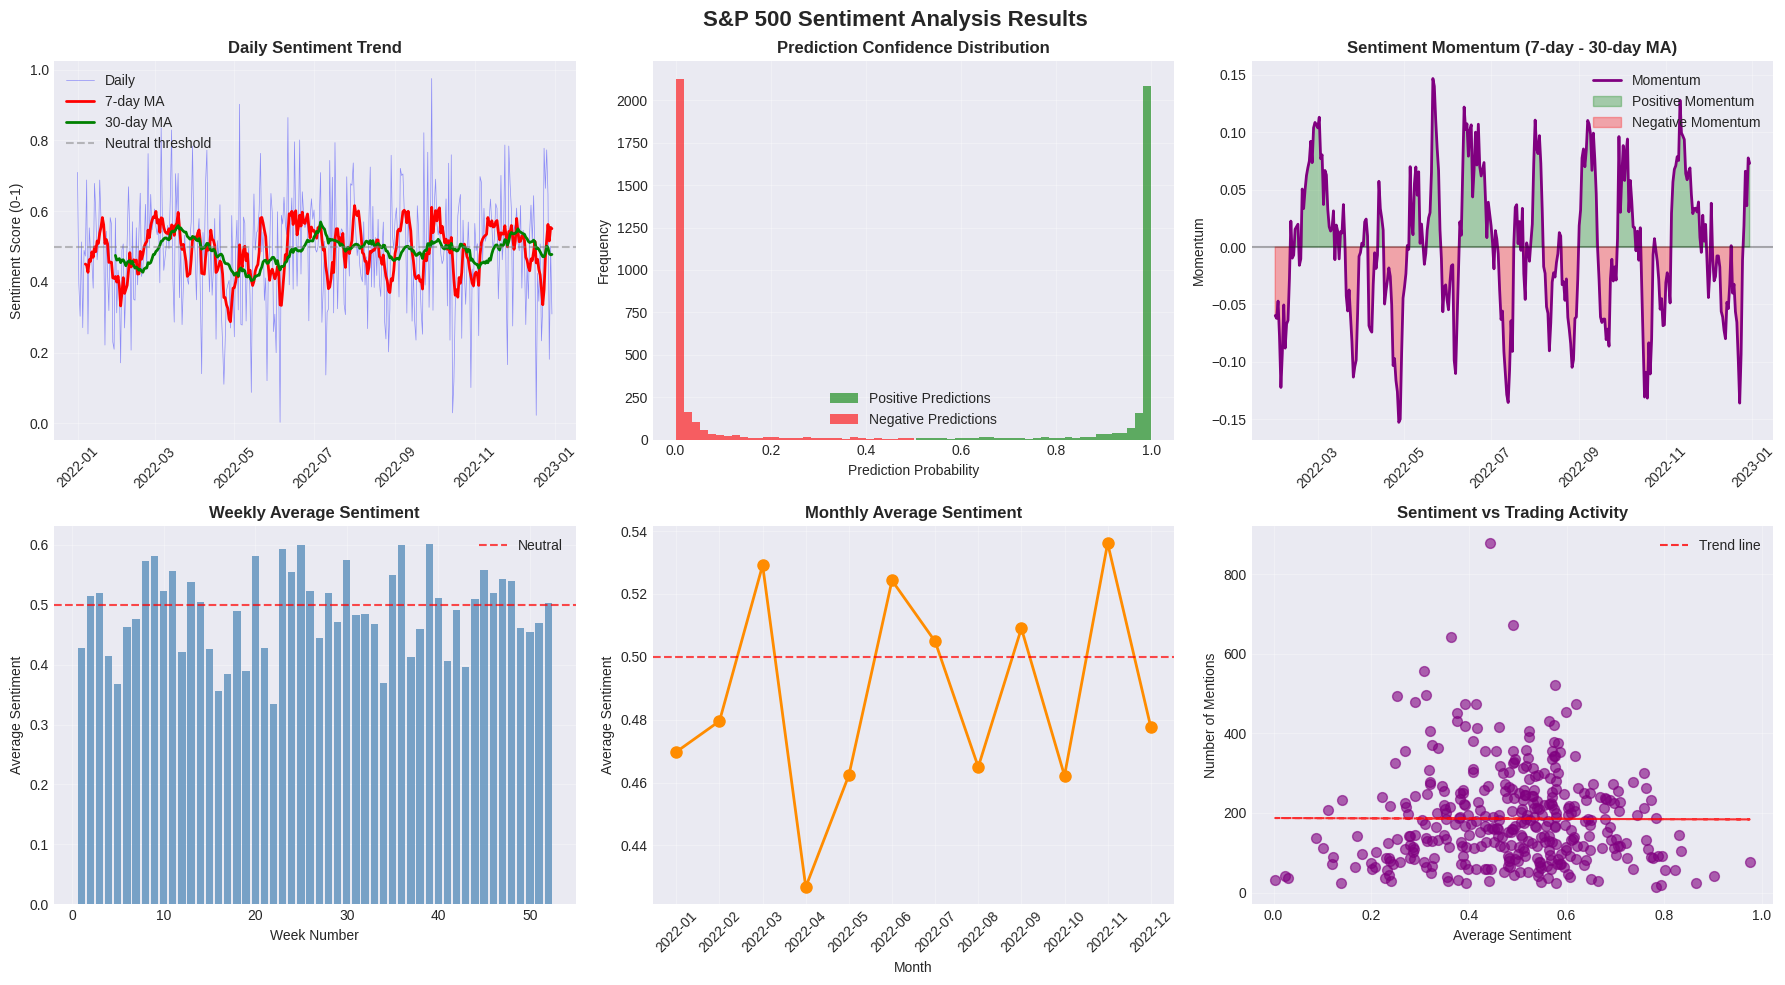


SENTIMENT ANALYSIS SUMMARY

📊 Data Coverage:
   - Date range: 2022-01-01 to 2022-12-30
   - Total days analyzed: 363
   - Total test samples: 5431

📈 Sentiment Statistics:
   - Mean sentiment: 0.4871
   - Median sentiment: 0.5063
   - Std deviation: 0.1614
   - Max sentiment: 0.9747
   - Min sentiment: 0.0034

🎯 Sentiment Distribution:
   - Positive days (>0.5): 186 (51.2%)
   - Negative days (<0.5): 177 (48.8%)
   - Neutral days (=0.5): 0 (0.0%)

🔥 Top 5 Most Bullish Days:
   - 2022-09-29: 0.9747 (mentions: 76.0)
   - 2022-05-05: 0.9020 (mentions: 42.0)
   - 2022-06-11: 0.8645 (mentions: 23.0)
   - 2022-03-06: 0.8352 (mentions: 104.0)
   - 2022-03-14: 0.8295 (mentions: 145.0)

📉 Top 5 Most Bearish Days:
   - 2022-06-05: 0.0034 (mentions: 31.0)
   - 2022-12-18: 0.0231 (mentions: 42.0)
   - 2022-10-15: 0.0301 (mentions: 37.0)
   - 2022-05-14: 0.0878 (mentions: 137.0)
   - 2022-10-29: 0.1015 (mentions: 113.0)


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Check what columns we actually have
print("Daily overall columns:", daily_overall.columns.tolist())
print("Test dataframe columns:", test_df.columns.tolist())

# Set style for better looking plots
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Determine which column names exist
if 'avg_sentiment' in daily_overall.columns:
    sentiment_col = 'avg_sentiment'
elif 'weighted_sentiment' in daily_overall.columns:
    sentiment_col = 'weighted_sentiment'
elif 'pred_prob' in daily_overall.columns:
    sentiment_col = 'pred_prob'
else:
    # Check for any column that might contain sentiment
    possible_cols = [col for col in daily_overall.columns if 'sentiment' in col.lower()]
    sentiment_col = possible_cols[0] if possible_cols else daily_overall.columns[1]
    print(f"Using column: {sentiment_col}")

print(f"Using sentiment column: {sentiment_col}")

# Create comprehensive visualization
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('S&P 500 Sentiment Analysis Results', fontsize=16, fontweight='bold')

# 1. Overall daily sentiment with moving averages
axes[0, 0].plot(daily_overall['date'], daily_overall[sentiment_col],
                alpha=0.4, label='Daily', linewidth=0.5, color='blue')

# Check if moving averages exist
if 'sentiment_ma7' in daily_overall.columns:
    axes[0, 0].plot(daily_overall['date'], daily_overall['sentiment_ma7'],
                    'r-', label='7-day MA', linewidth=2)
if 'sentiment_ma30' in daily_overall.columns:
    axes[0, 0].plot(daily_overall['date'], daily_overall['sentiment_ma30'],
                    'g-', label='30-day MA', linewidth=2)

axes[0, 0].axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='Neutral threshold')
axes[0, 0].set_title('Daily Sentiment Trend', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Sentiment Score (0-1)')
axes[0, 0].legend(loc='best')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].tick_params(axis='x', rotation=45)

# 2. Sentiment distribution histogram (using test_df)
if 'pred_prob' in test_df.columns:
    axes[0, 1].hist(test_df['pred_prob'][test_df['pred_label']==1],
                    alpha=0.6, label='Positive Predictions', bins=30, color='green')
    axes[0, 1].hist(test_df['pred_prob'][test_df['pred_label']==0],
                    alpha=0.6, label='Negative Predictions', bins=30, color='red')
elif sentiment_col in test_df.columns:
    axes[0, 1].hist(test_df[sentiment_col], bins=30, alpha=0.7, color='steelblue')

axes[0, 1].set_title('Prediction Confidence Distribution', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Prediction Probability')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. Sentiment momentum
if 'momentum' in daily_overall.columns:
    axes[0, 2].plot(daily_overall['date'], daily_overall['momentum'],
                    'purple', linewidth=2, label='Momentum')
    axes[0, 2].axhline(y=0, color='black', linestyle='-', alpha=0.3)
    axes[0, 2].fill_between(daily_overall['date'], 0, daily_overall['momentum'],
                             where=(daily_overall['momentum']>0), color='green', alpha=0.3, label='Positive Momentum')
    axes[0, 2].fill_between(daily_overall['date'], 0, daily_overall['momentum'],
                             where=(daily_overall['momentum']<0), color='red', alpha=0.3, label='Negative Momentum')
    axes[0, 2].set_title('Sentiment Momentum (7-day - 30-day MA)', fontsize=12, fontweight='bold')
    axes[0, 2].set_ylabel('Momentum')
    axes[0, 2].legend(loc='best')
    axes[0, 2].grid(True, alpha=0.3)
    axes[0, 2].tick_params(axis='x', rotation=45)
else:
    axes[0, 2].text(0.5, 0.5, 'Momentum data not available',
                    ha='center', va='center', transform=axes[0, 2].transAxes)
    axes[0, 2].set_title('Sentiment Momentum', fontsize=12, fontweight='bold')

# 4. Weekly average sentiment
if len(daily_overall) >= 7:
    daily_overall['week'] = pd.to_datetime(daily_overall['date']).dt.isocalendar().week
    weekly_sentiment = daily_overall.groupby('week')[sentiment_col].mean().reset_index()

    axes[1, 0].bar(weekly_sentiment['week'], weekly_sentiment[sentiment_col],
                   alpha=0.7, color='steelblue')
    axes[1, 0].axhline(y=0.5, color='red', linestyle='--', alpha=0.7, label='Neutral')
    axes[1, 0].set_title('Weekly Average Sentiment', fontsize=12, fontweight='bold')
    axes[1, 0].set_xlabel('Week Number')
    axes[1, 0].set_ylabel('Average Sentiment')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)

# 5. Monthly sentiment trends
if len(daily_overall) >= 30:
    daily_overall['month'] = pd.to_datetime(daily_overall['date']).dt.to_period('M')
    monthly_sentiment = daily_overall.groupby('month')[sentiment_col].mean().reset_index()
    monthly_sentiment['month_str'] = monthly_sentiment['month'].astype(str)

    axes[1, 1].plot(monthly_sentiment['month_str'], monthly_sentiment[sentiment_col],
                    marker='o', linewidth=2, markersize=8, color='darkorange')
    axes[1, 1].axhline(y=0.5, color='red', linestyle='--', alpha=0.7)
    axes[1, 1].set_title('Monthly Average Sentiment', fontsize=12, fontweight='bold')
    axes[1, 1].set_xlabel('Month')
    axes[1, 1].set_ylabel('Average Sentiment')
    axes[1, 1].grid(True, alpha=0.3)
    axes[1, 1].tick_params(axis='x', rotation=45)

# 6. Trading volume vs sentiment correlation
mention_col = None
for col in ['total_mentions', 'total_ticker_mentions', 'ticker_count', 'mention_count']:
    if col in daily_overall.columns:
        mention_col = col
        break

if mention_col:
    axes[1, 2].scatter(daily_overall[sentiment_col], daily_overall[mention_col],
                       alpha=0.6, c='purple', s=50)
    axes[1, 2].set_title('Sentiment vs Trading Activity', fontsize=12, fontweight='bold')
    axes[1, 2].set_xlabel('Average Sentiment')
    axes[1, 2].set_ylabel('Number of Mentions')
    axes[1, 2].grid(True, alpha=0.3)

    # Add trend line
    mask = ~(daily_overall[sentiment_col].isna() | daily_overall[mention_col].isna())
    if mask.sum() > 1:
        z = np.polyfit(daily_overall.loc[mask, sentiment_col],
                       daily_overall.loc[mask, mention_col], 1)
        p = np.poly1d(z)
        axes[1, 2].plot(daily_overall.loc[mask, sentiment_col],
                        p(daily_overall.loc[mask, sentiment_col]),
                        "r--", alpha=0.8, label='Trend line')
        axes[1, 2].legend()
else:
    axes[1, 2].text(0.5, 0.5, 'Mention data not available',
                    ha='center', va='center', transform=axes[1, 2].transAxes)
    axes[1, 2].set_title('Sentiment vs Trading Activity', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

# Print summary statistics using correct column names
print("\n" + "="*60)
print("SENTIMENT ANALYSIS SUMMARY")
print("="*60)

print(f"\n📊 Data Coverage:")
print(f"   - Date range: {daily_overall['date'].min()} to {daily_overall['date'].max()}")
print(f"   - Total days analyzed: {len(daily_overall)}")
print(f"   - Total test samples: {len(test_df)}")

print(f"\n📈 Sentiment Statistics:")
print(f"   - Mean sentiment: {daily_overall[sentiment_col].mean():.4f}")
print(f"   - Median sentiment: {daily_overall[sentiment_col].median():.4f}")
print(f"   - Std deviation: {daily_overall[sentiment_col].std():.4f}")
print(f"   - Max sentiment: {daily_overall[sentiment_col].max():.4f}")
print(f"   - Min sentiment: {daily_overall[sentiment_col].min():.4f}")

print(f"\n🎯 Sentiment Distribution:")
positive_days = (daily_overall[sentiment_col] > 0.5).sum()
negative_days = (daily_overall[sentiment_col] < 0.5).sum()
neutral_days = (daily_overall[sentiment_col] == 0.5).sum()
print(f"   - Positive days (>0.5): {positive_days} ({positive_days/len(daily_overall)*100:.1f}%)")
print(f"   - Negative days (<0.5): {negative_days} ({negative_days/len(daily_overall)*100:.1f}%)")
print(f"   - Neutral days (=0.5): {neutral_days} ({neutral_days/len(daily_overall)*100:.1f}%)")

# Top bullish/bearish days
print(f"\n🔥 Top 5 Most Bullish Days:")
top_bullish = daily_overall.nlargest(5, sentiment_col)[['date', sentiment_col]]
if mention_col:
    top_bullish = daily_overall.nlargest(5, sentiment_col)[['date', sentiment_col, mention_col]]
for idx, row in top_bullish.iterrows():
    if mention_col:
        print(f"   - {row['date']}: {row[sentiment_col]:.4f} (mentions: {row[mention_col]})")
    else:
        print(f"   - {row['date']}: {row[sentiment_col]:.4f}")

print(f"\n📉 Top 5 Most Bearish Days:")
top_bearish = daily_overall.nsmallest(5, sentiment_col)[['date', sentiment_col]]
if mention_col:
    top_bearish = daily_overall.nsmallest(5, sentiment_col)[['date', sentiment_col, mention_col]]
for idx, row in top_bearish.iterrows():
    if mention_col:
        print(f"   - {row['date']}: {row[sentiment_col]:.4f} (mentions: {row[mention_col]})")
    else:
        print(f"   - {row['date']}: {row[sentiment_col]:.4f}")

## Step 8: Export Results

Export and Documentation phase. It ensures that all the AI's "hard work" is saved in permanent files for reporting, sharing, or further analysis in other tools like Excel or Tableau.

1. Data Persistence (CSV Exports)
- The script saves the core results into two main spreadsheets:
  - daily_sentiment_results.csv: This is the "big picture" file. It contains the daily sentiment scores, mention counts, and trends for the S&P 500.
  - test_predictions.csv: This is the "granular" file. It saves individual Reddit post titles along with the specific sentiment label the AI assigned to them, allowing you to manually audit the model's logic.

2. Automated Reporting (model_performance_summary.txt)
- The code generates a professional text summary that acts as a "report card" for the project. It automatically extracts and writes:
  - Best Model Metrics: The peak F1-score, Accuracy, and Precision achieved during training.
  - Market Statistics: The percentage of "Bullish" vs. "Bearish" days found in the data.
  - Coverage Data: The total date range and number of samples processed.

3. Final Visual Output
As a safety measure, it generates and saves a standalone image (sentiment_trend.png). This provides a quick visual reference of the sentiment timeline that can be dropped into a presentation or document without needing to run the code again.

Daily overall columns: ['date', 'weighted_sentiment', 'total_mentions', 'num_tickers', 'sentiment_ma7', 'sentiment_ma30', 'momentum', 'week', 'month']
Test dataframe columns: ['id', 'title', 'text', 'created_utc', 'created_datetime', 'author', 'score', 'num_comments', 'upvote_ratio', 'flair', 'permalink', 'url', 'subreddit', 'company', 'tickers_title', 'tickers_text', 'tickers', 'has_ticker', 'ticker_count', 'enhanced_sentiment', 'ticker_confidence', 'label', 'label_binary', 'enhanced_text', 'pred_label', 'pred_prob', 'date']
Using sentiment column: weighted_sentiment
✅ Daily sentiment saved to 'daily_sentiment_results.csv'
✅ Test predictions saved to 'test_predictions.csv' with columns: ['date', 'pred_label', 'pred_prob', 'title', 'tickers']
✅ Model performance summary saved to 'model_performance_summary.txt'


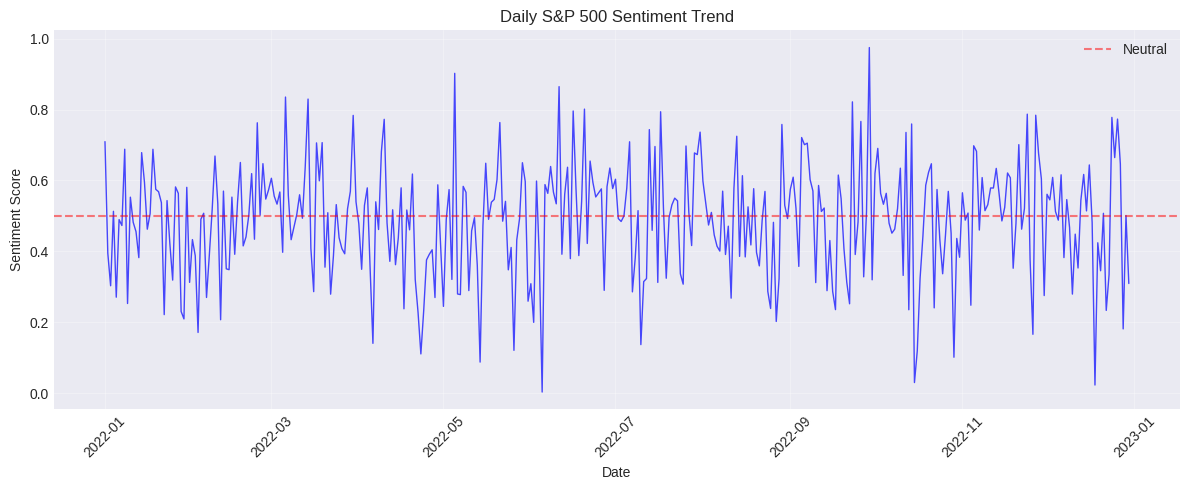

✅ Sentiment trend plot saved as 'sentiment_trend.png'

✅ All exports completed successfully!


In [10]:
# First, identify the correct column names in data
print("Daily overall columns:", daily_overall.columns.tolist())
print("Test dataframe columns:", test_df.columns.tolist())

# Find the sentiment column in daily_overall
sentiment_col = None
for col in ['avg_sentiment', 'weighted_sentiment', 'pred_prob', 'sentiment_score', 'avg_sentiment_score']:
    if col in daily_overall.columns:
        sentiment_col = col
        break

if sentiment_col is None:
    # Use the first numeric column that's not 'date' or index
    for col in daily_overall.columns:
        if col != 'date' and pd.api.types.is_numeric_dtype(daily_overall[col]):
            sentiment_col = col
            break

print(f"Using sentiment column: {sentiment_col}")

# Find mention column if it exists
mention_col = None
for col in ['total_mentions', 'total_ticker_mentions', 'mention_count', 'ticker_count']:
    if col in daily_overall.columns:
        mention_col = col
        break

# Save daily sentiment to CSV
daily_overall.to_csv("daily_sentiment_results.csv", index=False)
print("✅ Daily sentiment saved to 'daily_sentiment_results.csv'")

# Save test predictions (check which columns exist)
test_columns_to_save = []
for col in ['date', 'pred_label', 'pred_prob', 'title', 'tickers']:
    if col in test_df.columns:
        test_columns_to_save.append(col)

if test_columns_to_save:
    test_df[test_columns_to_save].to_csv("test_predictions.csv", index=False)
    print(f"✅ Test predictions saved to 'test_predictions.csv' with columns: {test_columns_to_save}")
else:
    print("⚠ Could not save test predictions - required columns not found")
    # Save whatever is available
    test_df.to_csv("test_predictions_full.csv", index=False)
    print("✅ Full test dataframe saved to 'test_predictions_full.csv'")

# Calculate sentiment statistics
positive_days = (daily_overall[sentiment_col] > 0.5).sum() if sentiment_col else 0
negative_days = (daily_overall[sentiment_col] < 0.5).sum() if sentiment_col else 0
neutral_days = (daily_overall[sentiment_col] == 0.5).sum() if sentiment_col else 0

# Save model performance summary
with open("model_performance_summary.txt", "w") as f:
    f.write("="*60 + "\n")
    f.write("MODEL PERFORMANCE SUMMARY\n")
    f.write("="*60 + "\n\n")

    # Get best metrics from training
    if hasattr(trainer, 'state') and trainer.state.log_history:
        best_f1 = 0
        best_accuracy = 0
        best_precision = 0
        best_recall = 0

        for log in trainer.state.log_history:
            if 'eval_f1' in log and log['eval_f1'] > best_f1:
                best_f1 = log['eval_f1']
            if 'eval_accuracy' in log and log['eval_accuracy'] > best_accuracy:
                best_accuracy = log['eval_accuracy']
            if 'eval_precision' in log and log['eval_precision'] > best_precision:
                best_precision = log['eval_precision']
            if 'eval_recall' in log and log['eval_recall'] > best_recall:
                best_recall = log['eval_recall']

        f.write("MODEL PERFORMANCE:\n")
        f.write(f"  Best F1 Score: {best_f1:.4f}\n")
        f.write(f"  Best Accuracy: {best_accuracy:.4f}\n")
        f.write(f"  Best Precision: {best_precision:.4f}\n")
        f.write(f"  Best Recall: {best_recall:.4f}\n")
        f.write("\n")

    # Sentiment statistics
    if sentiment_col:
        f.write("SENTIMENT STATISTICS:\n")
        f.write(f"  Mean sentiment: {daily_overall[sentiment_col].mean():.4f}\n")
        f.write(f"  Median sentiment: {daily_overall[sentiment_col].median():.4f}\n")
        f.write(f"  Std deviation: {daily_overall[sentiment_col].std():.4f}\n")
        f.write(f"  Max sentiment: {daily_overall[sentiment_col].max():.4f}\n")
        f.write(f"  Min sentiment: {daily_overall[sentiment_col].min():.4f}\n")
        f.write(f"  Positive days (>0.5): {positive_days}/{len(daily_overall)} ({positive_days/len(daily_overall)*100:.1f}%)\n")
        f.write(f"  Negative days (<0.5): {negative_days}/{len(daily_overall)} ({negative_days/len(daily_overall)*100:.1f}%)\n")
        f.write(f"  Neutral days (=0.5): {neutral_days}/{len(daily_overall)} ({neutral_days/len(daily_overall)*100:.1f}%)\n")
        f.write("\n")

    # Data coverage
    f.write("DATA COVERAGE:\n")
    f.write(f"  Date range: {daily_overall['date'].min()} to {daily_overall['date'].max()}\n")
    f.write(f"  Total days analyzed: {len(daily_overall)}\n")
    f.write(f"  Total test samples: {len(test_df)}\n")

    if mention_col:
        f.write(f"  Total mentions: {daily_overall[mention_col].sum()}\n")

print("✅ Model performance summary saved to 'model_performance_summary.txt'")

# Optional: Create a simple plot without plotly
try:
    import matplotlib.pyplot as plt

    plt.figure(figsize=(12, 5))
    plt.plot(daily_overall['date'], daily_overall[sentiment_col], 'b-', linewidth=1, alpha=0.7)
    plt.axhline(y=0.5, color='r', linestyle='--', alpha=0.5, label='Neutral')
    plt.title('Daily S&P 500 Sentiment Trend')
    plt.xlabel('Date')
    plt.ylabel('Sentiment Score')
    plt.xticks(rotation=45)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('sentiment_trend.png', dpi=100, bbox_inches='tight')
    plt.show()
    print("✅ Sentiment trend plot saved as 'sentiment_trend.png'")
except Exception as e:
    print(f"⚠ Could not save plot: {e}")

print("\n✅ All exports completed successfully!")

An Inference Pipeline optimized for speed. It takes the model you just trained and applies it to a large dataset to generate real-world financial signals quickly.

1. Optimized Model Loading
  - Hardware Acceleration: It automatically detects if a GPU (CUDA) is available. If so, it moves the entire model onto the graphics card, which can process text up to 20–50x faster than a standard CPU.
  - Pre-trained Weights: It loads the specific "brain" (./sentiment_model) you saved in the previous step.

2. High-Speed "Batch" Processing
- Instead of analyzing posts one by one (which is slow), the fast_predict function uses Batching:
  - Groups of 512: It feeds 512 posts into the AI at a single time.
  - Memory Management: It uses torch.no_grad(), which tells the computer: "We aren't learning anymore, just predicting." This significantly reduces memory usage and speeds up the math.
  - Truncation: It limits text to the first 128 tokens, focusing on the "meat" of the Reddit post to save time.

3. Data Aggregation & Output
- The script produces two distinct levels of data:
  - The Raw Level (predictions.csv): Every single Reddit post from 2024, now tagged with a precise sentiment score (0 to 1).
  - The Signal Level (daily.csv): A daily "Pulse" of the S&P 500. This tracks the average mood and the volume of discussion (post count) for every day of the year.

In [11]:
import pandas as pd
import numpy as np
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# Load model once
model = AutoModelForSequenceClassification.from_pretrained('./sentiment_model')
tokenizer = AutoTokenizer.from_pretrained('./sentiment_model')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

# Load data
from datasets import load_dataset
dataset = load_dataset("emilpartow/reddit_finance_posts_sp500")
df = dataset['train'].to_pandas()

# Filter and prepare
df = df[(pd.to_datetime(df['created_datetime']) >= '2022-01-01') &
        (pd.to_datetime(df['created_datetime']) <= '2022-12-31')]
df['text'] = (df['title'].fillna('') + " " + df['text'].fillna('')).str[:300]

# Batch predict
def fast_predict(texts, batch_size=512):
    scores = []
    for i in range(0, len(texts), batch_size):
        inputs = tokenizer(texts[i:i+batch_size], truncation=True, padding=True,
                          max_length=128, return_tensors="pt").to(device)
        with torch.no_grad():
            probs = torch.softmax(model(**inputs).logits, dim=-1)
            scores.extend(probs[:, 1].cpu().numpy())
    return np.array(scores)

# Run prediction
df['sentiment'] = fast_predict(df['text'].tolist())

# Quick daily aggregation
df['date'] = pd.to_datetime(df['created_datetime']).dt.date
daily = df.groupby('date')['sentiment'].agg(['mean', 'count']).reset_index()
daily.columns = ['date', 'sentiment', 'post_count']

# Save
df.to_csv('predictions.csv', index=False)
daily.to_csv('daily.csv', index=False)

print(f"✅ Done! {len(df):,} posts processed")
print(f"   Avg sentiment: {df['sentiment'].mean():.4f}")

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

✅ Done! 52,850 posts processed
   Avg sentiment: 0.5960


In [12]:
import os
from google.colab import files

# 1. Define where to save
save_path = "./sentiment_model"
if not os.path.exists(save_path):
    os.makedirs(save_path)

# 2. Save the model and tokenizer
# Replace 'model' and 'tokenizer' with your actual variable names from Colab
model.save_pretrained(save_path)
tokenizer.save_pretrained(save_path)

# 3. Zip the folder so it's one file
!zip -r sentiment_model.zip ./sentiment_model

# 4. Trigger the download to your computer
files.download("sentiment_model.zip")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  adding: sentiment_model/ (stored 0%)
  adding: sentiment_model/config.json (deflated 52%)
  adding: sentiment_model/model.safetensors (deflated 8%)
  adding: sentiment_model/tokenizer.json (deflated 71%)
  adding: sentiment_model/tokenizer_config.json (deflated 49%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Summary

📁 FILES GENERATED:
────────────────────────────────────────────────
   1. daily.csv - Daily sentiment scores and post counts
   2. daily_sentiment_results.csv - Daily sentiment scores and Sentiment Momentum Oscillator scores
   3. test_predictions_full.csv - All test predictions
   4. predictions.csv - All individual post predictions
   5. sentiment_model/ - Trained model files
   6. model_performance_summary.txt - Quick summary of results
   7. sentiment_trend.png - Sentiment visualization

📊 WHAT YOU CAN DO NEXT:
────────────────────────────────────────────────
   1. Load the saved model for future predictions
   2. Analyze daily_sentiment_results.csv in Excel/Python
   3. Correlate sentiment with S&P 500 price movements
   4. Identify patterns before market movements
   5. Create trading signals based on sentiment thresholds

✅ All steps completed! You can now download the generated files.


🔮 TO LOAD THE MODEL LATER:
────────────────────────────────────────────────

In [ ]:
from transformers import AutoModelForSequenceClassification, AutoTokenizer

model = AutoModelForSequenceClassification.from_pretrained('./sentiment_model')
tokenizer = AutoTokenizer.from_pretrained('./sentiment_model')

# Make predictions on new text
inputs = tokenizer("Your text here", return_tensors="pt", truncation=True)
outputs = model(**inputs)
prediction = torch.argmax(outputs.logits, dim=-1)